In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/training_dataset.csv")
print(f"Total peptides: {len(df)}")
print(df['activity_label'].value_counts())
print(df.describe().round(2))

Total peptides: 3913
activity_label
0    2739
1    1174
Name: count, dtype: int64
        length  net_charge  hydrophobicity  activity_label  molecular_weight  \
count  3913.00     3913.00         3913.00         3913.00           3913.00   
mean     14.61        2.88           -0.22            0.30           1761.50   
std       3.49        2.97            1.16            0.46            420.06   
min       8.00       -8.15           -4.50            0.00            725.83   
25%      12.00        0.76           -0.88            0.00           1448.79   
50%      15.00        2.84           -0.13            0.00           1738.21   
75%      18.00        4.76            0.55            1.00           2092.53   
max      20.00       15.76            3.80            1.00           3225.68   

       instability_index  isoelectric_point  aromaticity  helix_fraction  \
count            3913.00            3913.00      3913.00         3913.00   
mean               45.20               9.53  

In [3]:
FEATURES = [
    'length', 'molecular_weight', 'net_charge',
    'hydrophobicity', 'instability_index',
    'isoelectric_point', 'aromaticity',
    'helix_fraction', 'turn_fraction', 'sheet_fraction',
    'pct_hydrophobic', 'pct_positive',
    'pct_negative', 'pct_polar'
]

X = df[FEATURES]        # features — what the model sees
y = df['activity_label']  # target — what it tries to predict

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")

Features: 14
Samples:  3913


In [4]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
# stratify=y ensures both sets have same ratio of active/inactive
# random_state=42 makes results reproducible — same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {len(X_train)} peptides")
print(f"Testing set  : {len(X_test)} peptides")

Training set : 3130 peptides
Testing set  : 783 peptides


In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Three models to try — we pick the best one
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,       # 200 decision trees
        random_state=42,
        class_weight='balanced'  # handles imbalanced data (more inactive than active)
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),  # SVM needs scaled features
        ('svm', SVC(
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ])
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'auc': auc,
        'pred': y_pred,
        'prob': y_prob
    }
    print(f"  AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred,
          target_names=['Inactive','Active']))


Training Random Forest...
  AUC: 0.891
              precision    recall  f1-score   support

    Inactive       0.86      0.93      0.89       548
      Active       0.79      0.64      0.71       235

    accuracy                           0.84       783
   macro avg       0.83      0.78      0.80       783
weighted avg       0.84      0.84      0.84       783


Training Gradient Boosting...
  AUC: 0.836
              precision    recall  f1-score   support

    Inactive       0.82      0.91      0.86       548
      Active       0.72      0.54      0.62       235

    accuracy                           0.80       783
   macro avg       0.77      0.72      0.74       783
weighted avg       0.79      0.80      0.79       783


Training SVM...
  AUC: 0.797
              precision    recall  f1-score   support

    Inactive       0.89      0.64      0.74       548
      Active       0.49      0.81      0.61       235

    accuracy                           0.69       783
   macro avg  

Best model: Random Forest  AUC = 0.891


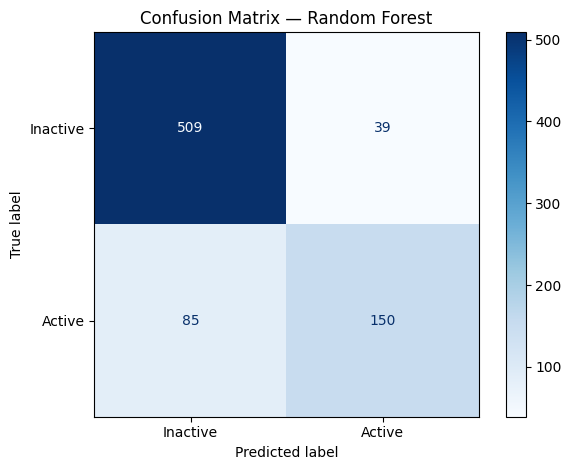

In [6]:
# Pick the best model by AUC score
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
print(f"Best model: {best_name}  AUC = {best['auc']:.3f}")

# Confusion matrix — shows TP, TN, FP, FN
os.makedirs("../models", exist_ok=True)
cm = confusion_matrix(y_test, best['pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Inactive','Active'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=150)
plt.show()

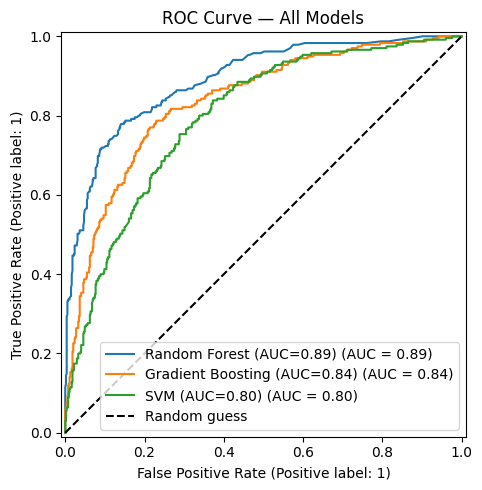

In [7]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
for name, r in results.items():
    RocCurveDisplay.from_predictions(
        y_test, r['prob'],
        name=f"{name} (AUC={r['auc']:.2f})",
        ax=ax
    )
ax.plot([0,1],[0,1],'k--',label='Random guess')
ax.set_title("ROC Curve — All Models")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../models/roc_curve.png", dpi=150)
plt.show()

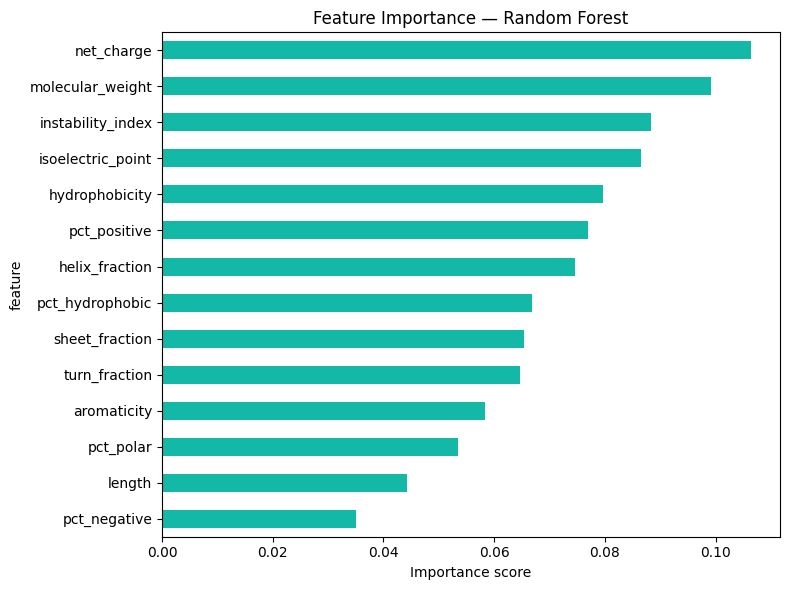

In [8]:
# Only works for Random Forest — shows which features the model relied on most
rf = results['Random Forest']['model']
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

importance.plot(kind='barh', x='feature', y='importance',
    figsize=(8,6), legend=False, color='#14b8a6')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance score")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=150)
plt.show()

In [9]:
# Save the trained model to disk
# joblib is faster than pickle for scikit-learn models
joblib.dump(best['model'], "../models/amp_classifier.pkl")
joblib.dump(FEATURES, "../models/feature_names.pkl")

print(f"✅ Saved: models/amp_classifier.pkl")
print(f"   Model : {best_name}")
print(f"   AUC   : {best['auc']:.3f}")

✅ Saved: models/amp_classifier.pkl
   Model : Random Forest
   AUC   : 0.891
